<a href="https://colab.research.google.com/github/hamzasaleem22/AI-RAG-CHATBOT/blob/main/Rag_pipline_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faiss-cpu sentence-transformers numpy langchain langchain-community   langchain-text-splitters

In [ ]:
  from google.colab import files
  uploaded=files.upload()
  for filename in uploaded.keys():
    print("uploaded:",filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report.pdf
uploaded: Microsoft 2025 Annual Report.pdf


In [ ]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file=list(uploaded.keys())[0]
loader=PyPDFLoader(pdf_file)
documents = loader.load()
print("Total number of chunks:", len(documents))

Total number of chunks: 65


In [ ]:

from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunks = text_splitter.split_documents(documents)

print("Total number of chunks:", len(chunks))

Total number of chunks: 702


In [ ]:
print(chunks[0].page_content)


HomeShareholder LetterFinancial ReviewBusinessGeneralOperating SegmentsHuman Capital ResourcesOperationsResearch & DevelopmentDistribution, Sales & MarketingLicensing OptionsGovernment RegulationAvailable InformationDiscussion & AnalysisMarket RiskIncome StatementsBalance SheetsCash Flows StatementsStockholders' EquityNotesAccounting PoliciesEarnings Per ShareOther Income (Expense), NetInvestmentsDerivativesProperty and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome


In [ ]:
print(chunks[1].page_content)

and EquipmentBusiness CombinationsGoodwillIntangible AssetsDebtIncome TaxesUnearned RevenueLeasesContingenciesStockholders' EquityAccumulated Other Comprehensive Income (Loss)Employee Stock and Savings PlansSegment Information & Geo DataAuditor's ReportControls & ProceduresDirectors & OfficersInvestor Relations


In [ ]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
#22 million parameter model

embeddings = embedding_model.encode([chunk.page_content for chunk in chunks])
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Total vectors in the index", index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total vectors in the index 702


In [ ]:
print(dimension)

384


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_embeddings(vector, chunk_text=None, max_text_chars=500):

    normalized = (vector - vector.min()) / (vector.max() - vector.min())


    color_band = normalized.reshape(1, -1)

    if chunk_text is not None:
        print("Chunk text:\n")
        print(chunk_text[:max_text_chars])
        print()

    plt.figure(figsize=(12, 2))
    plt.imshow(color_band, aspect="auto", cmap="viridis")
    plt.yticks([])
    plt.xlabel(f"Embedding Dimensions ({len(vector)})")
    plt.title("Vector Representation")
    plt.show()

Chunk text:

Striking this balance is hard work, and few companies over the years have been able to do it. To succeed, we must continue to think indecades but execute in quarters, approaching each day with the humility and curiosity required to continuously improve, while beingguided by our bold vision for the future.



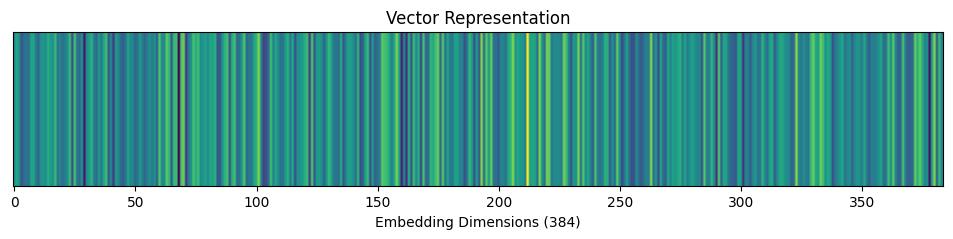

In [ ]:
visualize_embeddings(embeddings[5], chunks[5].page_content)


Enter your question: by how much percernt that micrsoft increase his revine from 2024 to 2025
Chunk text:

by how much percernt that micrsoft increase his revine from 2024 to 2025



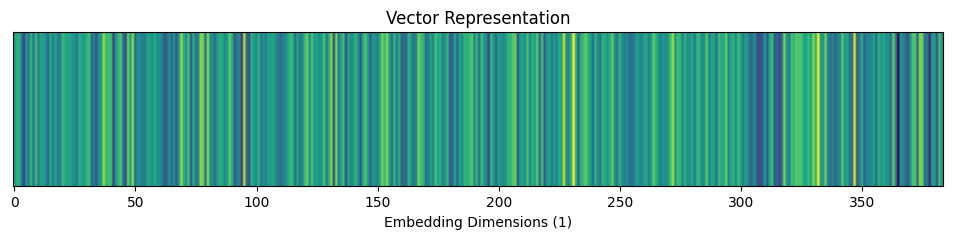

In [ ]:
query = input("Enter your question: ")
query_embedding = embedding_model.encode([query])

visualize_embeddings(query_embedding, query)

In [ ]:
D, I = index.search(np.array(query_embedding), k = 5)
retrieved_chunks = [chunks[i] for i in I[0]]

print("Top retrieved chunks: \n")

for chunk in retrieved_chunks:
    print(chunk.page_content)
    print("Page:", chunk.metadata["page"])
    print("=============================================")

Top retrieved chunks: 

2025 also marked the midpoint in our journey to become a carbon negative, water positive, zero waste company, and to protect moreland than we use. We are on track to meet many of our targets and continue to accelerate progress for others.
Page: 3
2025 Impact
Foreign currency – Revenue10% decrease in foreign exchange rates (11,596)Earnings
Foreign currency – Investments10% decrease in foreign exchange rates (17) Fair Value
Interest rate 100 basis point increase in U.S. treasury interest rates(1,415)Fair Value
Credit 100 basis point increase in credit spreads (436) Fair Value
Equity 10% decrease in equity market prices (1,213)Earnings
FINANCIAL STATEMENTS AND SUPPLEMENTARY DATA
Annual Report 2025
home
Page: 27
$ $
$ $
$ $
$ $
(In millions, except percentages) 2025 2024
Percentage
Change
Research and development 32,488 29,510 10%
As a percent of revenue 12% 12% 0ppt
Page: 21
Year Ended June 30, 2025 2024 2023
Derivatives
Balance, beginning of period (3) (27) (13)
U

In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

pairs = [(query, chunk.page_content) for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores, retrieved_chunks),
                       key = lambda x: x[0],
                       reverse = True
                       )

print("After reranking: \n")

for score, chunk in ranked_chunks:
    print("score:", score)
    print(chunk.page_content)
    print("Page number: ", chunk)
    print("========================================================")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


After reranking: 

score: -4.27935
Year Ended June 30, 2025 2024 2023
Derivatives
Balance, beginning of period (3) (27) (13)
Unrealized gains (losses), net of tax of $20, $(4), and $9 77 (14) 34
Reclassification adjustments for (gains) losses included in other income (expense), net(103) 48 (61)
Tax expense (benefit) included in provision for income taxes 21 (10) 13
Amounts reclassified from accumulated other comprehensive loss(82) 38 (48)
Net change related to derivatives, net of tax of $(1), $6, and $(4) (5) 24 (14)
Page number:  page_content='Year Ended June 30, 2025 2024 2023
Derivatives
Balance, beginning of period (3) (27) (13)
Unrealized gains (losses), net of tax of $20, $(4), and $9 77 (14) 34
Reclassification adjustments for (gains) losses included in other income (expense), net(103) 48 (61)
Tax expense (benefit) included in provision for income taxes 21 (10) 13
Amounts reclassified from accumulated other comprehensive loss(82) 38 (48)
Net change related to derivatives, net of

In [ ]:
top_chunks =[chunks.page_content for _, chunks in ranked_chunks[:3]]
context ="\n\n".join(top_chunks)
print(context)


Year Ended June 30, 2025 2024 2023
Derivatives
Balance, beginning of period (3) (27) (13)
Unrealized gains (losses), net of tax of $20, $(4), and $9 77 (14) 34
Reclassification adjustments for (gains) losses included in other income (expense), net(103) 48 (61)
Tax expense (benefit) included in provision for income taxes 21 (10) 13
Amounts reclassified from accumulated other comprehensive loss(82) 38 (48)
Net change related to derivatives, net of tax of $(1), $6, and $(4) (5) 24 (14)

$ $
$ $
$ $
$ $
(In millions, except percentages) 2025 2024
Percentage
Change
Research and development 32,488 29,510 10%
As a percent of revenue 12% 12% 0ppt

2025 Impact
Foreign currency – Revenue10% decrease in foreign exchange rates (11,596)Earnings
Foreign currency – Investments10% decrease in foreign exchange rates (17) Fair Value
Interest rate 100 basis point increase in U.S. treasury interest rates(1,415)Fair Value
Credit 100 basis point increase in credit spreads (436) Fair Value
Equity 10% decreas

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder

# Initialize models (already done in previous cells, but included here for reference)
# If running this cell independently, uncomment the following:
# embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
# reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Assuming 'index' and 'chunks' are available from previous cells

# Configure Gemini API
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

conversation_history = []

print("Start chatting with your document! Type 'quit' or 'exit' to stop.")

while True:
    user_query = input("\nYour Question: ")
    if user_query.lower() in ["quit", "exit"]:
        print("Exiting chat. Goodbye!")
        break

    # 1. Generate query embedding
    query_embedding = embedding_model.encode([user_query])

    # 2. Retrieve relevant chunks using FAISS
    D, I = index.search(np.array(query_embedding), k=5)
    retrieved_chunks = [chunks[i] for i in I[0]]

    # 3. Rerank retrieved chunks for improved relevance
    pairs = [(user_query, chunk.page_content) for chunk in retrieved_chunks]
    scores = reranker.predict(pairs)
    ranked_chunks = sorted(
        zip(scores, retrieved_chunks),
        key=lambda x: x[0],
        reverse=True
    )

    # 4. Combine top reranked chunks into context
    top_chunks = [chunk.page_content for _, chunk in ranked_chunks[:3]]
    context = "\n\n".join(top_chunks)

    # 5. Build prompt with conversation history and new context
    messages = []
    for q, a in conversation_history:
        messages.append({"role": "user", "parts": [{"text": q}]})
        messages.append({"role": "model", "parts": [{"text": a}]})

    # Add the current query with the context
    current_prompt = f"""
Answer the question using the context below. Keep your answer concise.

Context:
{context}

Question:
{user_query}
"""
    messages.append({"role": "user", "parts": [{"text": current_prompt}]})

    # 6. Generate answer with LLM
    try:
        response = gemini_model.generate_content(messages)
        answer = response.text
        print("Answer:\n", answer)

        # 7. Display sources
        print("\nSources used:\n")
        for score, chunk in ranked_chunks[:3]:
            print("Page:", chunk.metadata["page"])
            # print(chunk.page_content[:400])
            print("------- ")

        # Add to conversation history
        conversation_history.append((user_query, answer))

    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Start chatting with your document! Type 'quit' or 'exit' to stop.

Your Question: hi
Answer:
 Hello! How can I help you today with the provided context about Microsoft's 2025 Annual Report and Gaming?

Sources used:

Page: 11
------- 
Page: 63
------- 
Page: 13
------- 

Your Question: quit
Exiting chat. Goodbye!


In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import nest_asyncio
from pyngrok import ngrok

app = FastAPI()

In [ ]:
from fastapi.middleware.cors import CORSMiddleware

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

In [ ]:
class Query(BaseModel):
    question: str

In [ ]:
@app.post("/chat")
def chat(query: Query):
    answer = rag_pipeline(query.question)
    return {"answer": answer}

In [ ]:
ngrok.set_auth_token("3EWvEmYqIqG0Lm5TNrfLKcEjW1l_3bMgi3QpjEUUFnGJM5T7h")

In [ ]:
from pyngrok import ngrok

# Close all open tunnels
for tunnel in ngrok.get_tunnels():
    ngrok.disconnect(tunnel.public_url)

# Now start fresh
public_url = ngrok.connect(786)
print(public_url)

NgrokTunnel: "https://eloise-uncomplicated-nonhedonically.ngrok-free.dev" -> "http://localhost:786"


In [ ]:

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import numpy as np

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

class Query(BaseModel):
    question: str

def rag_pipeline(user_query: str) -> str:
    # Step 1 — Embed the query
    query_embedding = embedding_model.encode([user_query])

    # Step 2 — Retrieve from FAISS
    D, I = index.search(np.array(query_embedding), k=5)
    retrieved_chunks = [chunks[i] for i in I[0]]

    # Step 3 — Rerank
    pairs = [(user_query, chunk.page_content) for chunk in retrieved_chunks]
    scores = reranker.predict(pairs)
    ranked_chunks = sorted(
        zip(scores, retrieved_chunks),
        key=lambda x: x[0],
        reverse=True
    )

    # Step 4 — Build context
    top_chunks = [chunk.page_content for _, chunk in ranked_chunks[:3]]
    context = "\n\n".join(top_chunks)

    # Step 5 — Call Gemini
    prompt = f"""Answer the question using the context below. Keep your answer concise.

Context:
{context}

Question:
{user_query}
"""
    response = gemini_model.generate_content(prompt)
    return response.text

@app.post("/chat")
def chat(query: Query):
    answer = rag_pipeline(query.question)
    return {"answer": answer}

In [ ]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(786)
print(public_url)

NgrokTunnel: "https://eloise-uncomplicated-nonhedonically.ngrok-free.dev" -> "http://localhost:786"


In [ ]:
import uvicorn
import nest_asyncio

nest_asyncio.apply()
config = uvicorn.Config(app, host="0.0.0.0", port=786, loop="asyncio")
server = uvicorn.Server(config)
await server.serve()

INFO:     Started server process [3227]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:786 (Press CTRL+C to quit)


INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "OPTIONS /chat HTTP/1.1" 200 OK


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1342.67ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 734.79ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1316.13ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1544.22ms


INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "OPTIONS /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK
INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 200 OK


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3211.67ms


...

INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

INFO:     203.215.174.87:0 - "OPTIONS /chat HTTP/1.1" 200 OK


INFO:     203.215.174.87:0 - "POST /chat HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [ ]:
ngrok.kill()
public_url = ngrok.connect(786)
print(public_url)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')